In [2]:
import numpy as np
import pandas as pd
import dask.dataframe as dd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# paths for the three dfs

df_jan_path = "/kaggle/input/datasets/elemento/nyc-yellow-taxi-trip-data/yellow_tripdata_2016-01.csv"
df_feb_path = "/kaggle/input/datasets/elemento/nyc-yellow-taxi-trip-data/yellow_tripdata_2016-02.csv"
df_mar_path = "/kaggle/input/datasets/elemento/nyc-yellow-taxi-trip-data/yellow_tripdata_2016-03.csv"

# load the dataframes

df_jan = dd.read_csv(df_jan_path, assume_missing=True)
df_feb = dd.read_csv(df_feb_path, assume_missing=True)
df_mar = dd.read_csv(df_mar_path, assume_missing=True)

In [5]:
# Step 1 (memory-safe): read only needed columns, then concat

df_final = dd.concat([df_jan, df_feb, df_mar], axis=0)

In [6]:
# Step 2.1: parse datetime safely  --> string to datetime
df_final["tpep_pickup_datetime"] = dd.to_datetime(df_final["tpep_pickup_datetime"], errors="coerce")
df_final["tpep_dropoff_datetime"] = dd.to_datetime(df_final["tpep_dropoff_datetime"], errors="coerce")


In [7]:
# Step 2.2: minimal cleaning rules

df_final["trip_duration_min"] = (
    (df_final["tpep_dropoff_datetime"] - df_final["tpep_pickup_datetime"]).dt.total_seconds() / 60.0
)

clean_df = df_final[
    (df_final["tpep_pickup_datetime"].notnull()) &
    (df_final["tpep_dropoff_datetime"].notnull()) &
    (df_final["trip_duration_min"] > 0) &
    (df_final["trip_distance"] > 0) &
    (df_final["fare_amount"] > 0)
]


In [8]:
# Step 2.3: sanity check
clean_df[["tpep_pickup_datetime", "tpep_dropoff_datetime", "trip_duration_min", "trip_distance", "fare_amount"]].head()

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_min,trip_distance,fare_amount
5,2016-01-01 00:00:00,2016-01-01 00:18:30,18.50,5.52,19.0
6,2016-01-01 00:00:00,2016-01-01 00:26:45,26.75,7.45,26.0
7,2016-01-01 00:00:01,2016-01-01 00:11:55,11.90,1.20,9.0
8,2016-01-01 00:00:02,2016-01-01 00:11:14,11.20,6.00,18.0
9,2016-01-01 00:00:02,2016-01-01 00:11:08,11.10,3.21,11.5


In [9]:
# datatypes

df_final.dtypes

VendorID                         float64
tpep_pickup_datetime      datetime64[ns]
tpep_dropoff_datetime     datetime64[ns]
passenger_count                  float64
trip_distance                    float64
pickup_longitude                 float64
pickup_latitude                  float64
RatecodeID                       float64
store_and_fwd_flag       string[pyarrow]
dropoff_longitude                float64
dropoff_latitude                 float64
payment_type                     float64
fare_amount                      float64
extra                            float64
mta_tax                          float64
tip_amount                       float64
tolls_amount                     float64
improvement_surcharge            float64
total_amount                     float64
trip_duration_min                float64
dtype: object

In [10]:
# CHanging datatypes of few cols
float_cols = [
    "VendorID", "passenger_count", "trip_distance",
    "pickup_longitude", "pickup_latitude", "RatecodeID",
    "dropoff_longitude", "dropoff_latitude", "payment_type",
    "fare_amount", "extra", "mta_tax", "tip_amount",
    "tolls_amount", "improvement_surcharge", "total_amount",
    "trip_duration_min"
]

for c in float_cols:
    if c in df_final.columns:
        df_final[c] = df_final[c].astype("float32")

if "store_and_fwd_flag" in df_final.columns:
    df_final["store_and_fwd_flag"] = df_final["store_and_fwd_flag"].astype("category")

df_final.dtypes


VendorID                        float32
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                 float32
trip_distance                   float32
pickup_longitude                float32
pickup_latitude                 float32
RatecodeID                      float32
store_and_fwd_flag             category
dropoff_longitude               float32
dropoff_latitude                float32
payment_type                    float32
fare_amount                     float32
extra                           float32
mta_tax                         float32
tip_amount                      float32
tolls_amount                    float32
improvement_surcharge           float32
total_amount                    float32
trip_duration_min               float32
dtype: object

<Axes: ylabel='trip_duration_min'>

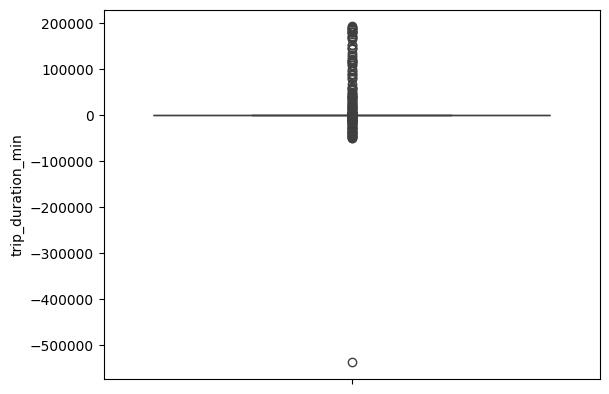

In [14]:
sns.boxplot(df_final.loc[:,"trip_duration_min"].compute())

In [14]:
location_subset = df_final[['pickup_latitude','pickup_longitude', 
                           'dropoff_latitude','dropoff_longitude']]

location_subset

,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude
npartitions=82,,,,
,float32,float32,float32,float32
,...,...,...,...
...,...,...,...,...
,...,...,...,...
,...,...,...,...


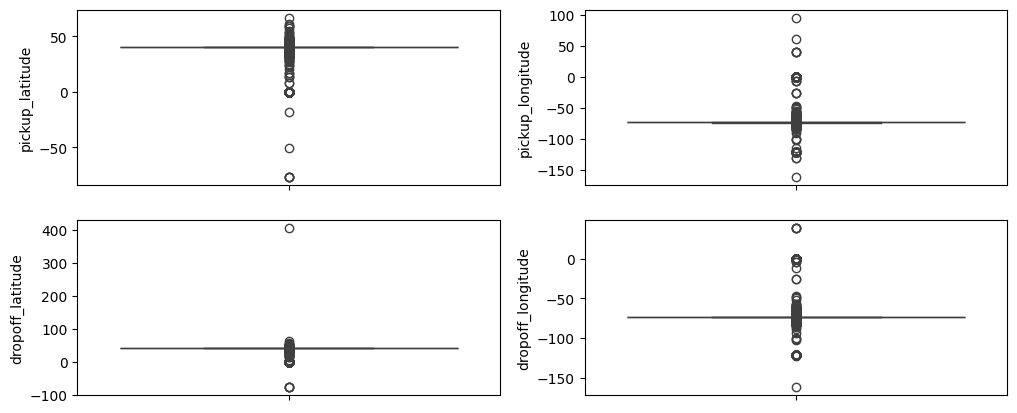

In [18]:
# boxplots for location based columns

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=2, figsize=(12,5))
for i in range(4):
    if i <= 1:
        # plot the boxplot
        sns.boxplot(y=location_subset.iloc[:,i].compute(),ax=ax1[i])
    else:
        # plot the boxplot
        sns.boxplot(y=location_subset.iloc[:,i].compute(),ax=ax2[i - 2])

In [12]:
# create new columns

df_final["pickup_months"] = df_final["tpep_pickup_datetime"].dt.month
df_final["pickup_day_of_week"] = df_final["tpep_pickup_datetime"].dt.dayofweek
df_final["pickup_hour"] = df_final["tpep_pickup_datetime"].dt.hour

## Creating zones interval for Arima/Sarima/Prophet models

In [16]:
# Use cleaned data for all downstream EDA
# ...existing code...
clean_df["pickup_months"] = clean_df["tpep_pickup_datetime"].dt.month
clean_df["pickup_day_of_week"] = clean_df["tpep_pickup_datetime"].dt.dayofweek
clean_df["pickup_hour"] = clean_df["tpep_pickup_datetime"].dt.hour
# ...existing code...

In [17]:
# ...existing code...

# Build zone_id safely
zone_df = clean_df[
    ["tpep_pickup_datetime", "pickup_latitude", "pickup_longitude",
     "trip_distance", "fare_amount", "trip_duration_min"]
].copy()

zone_df["lat_bin"] = zone_df["pickup_latitude"].round(2)
zone_df["lon_bin"] = zone_df["pickup_longitude"].round(2)
zone_df["zone_id"] = zone_df["lat_bin"].astype("string") + "_" + zone_df["lon_bin"].astype("string")

# Aggregate 1: means
zone_stats_pd = (
    zone_df.groupby("zone_id")
    .agg({
        "trip_distance": "mean",
        "fare_amount": "mean",
        "trip_duration_min": "mean"
    })
    .rename(columns={
        "trip_distance": "zone_avg_trip_distance",
        "fare_amount": "zone_avg_fare",
        "trip_duration_min": "zone_avg_duration_min"
    })
    .compute()
    .reset_index()
)

# Aggregate 2: counts
zone_counts_pd = (
    zone_df.groupby("zone_id")
    .size()
    .compute()
    .reset_index(name="zone_total_pickups")
)

# Merge in pandas (stable)
zone_features = zone_stats_pd.merge(zone_counts_pd, on="zone_id", how="left")

zone_features.sort_values("zone_total_pickups", ascending=False).head(20)
# ...existing code...

,zone_id,zone_avg_trip_distance,zone_avg_fare,zone_avg_duration_min,zone_total_pickups
300,40.76_-73.97,2.450951,10.801446,14.056462,2111856
2366,40.75_-73.99,2.727980,11.253372,15.301053,2102891
301,40.76_-73.98,2.572961,11.910529,15.804504,1849074
3,40.75_-73.98,2.576258,11.063191,14.420042,1710063
1452,40.74_-73.99,3.902939,10.606939,14.233464,1555377
1755,40.76_-73.99,2.818830,11.674309,14.945925,1547690
1451,40.73_-73.99,3.272118,11.013995,15.096505,1223634
875,40.77_-73.96,1.981523,9.739630,12.724777,1197193
2674,40.77_-73.98,2.552782,10.820519,14.400764,1096118
1758,40.73_-74.0,18.489474,11.127948,15.094981,1035242


In [ ]:
# each zone’s peak pickup hour

# What: find the busiest hour for each zone
# Why: captures zone-specific temporal behavior (business vs residential vs transit patterns)

zone_hour_pd = (
    zone_df.assign(pickup_hour=zone_df["tpep_pickup_datetime"].dt.hour)
    .groupby(["zone_id", "pickup_hour"])
    .size()
    .compute()
    .reset_index(name="pickup_count")
)

zone_peak_hour = (
    zone_hour_pd.sort_values(["zone_id", "pickup_count"], ascending=[True, False])
    .drop_duplicates("zone_id")
    .rename(columns={"pickup_hour": "zone_peak_hour"})
    [["zone_id", "zone_peak_hour"]]
)

zone_features = zone_features.merge(zone_peak_hour, on="zone_id", how="left")
zone_features.head()

# Notebook 2

In [ ]:
# ...existing code...
# Step 1: Keep all useful columns for hidden-pattern analysis.
# (Do NOT drop trip_distance, fare_amount, dropoff coordinates yet.)

# old (disable/remove):
# df_final = df_final.drop(columns=['trip_distance', 'dropoff_longitude', 'dropoff_latitude', 'fare_amount'])

print("Current columns:", list(df_final.columns))

In [18]:
# set the values of coordinates

min_latitude = 40.60
max_latitude = 40.85

min_longitude = -74.05
max_longitude = -73.70

In [19]:
# select data points within the given ranges

df_final = df_final.loc[(df_final["pickup_latitude"].between(min_latitude, max_latitude, inclusive="both")) & 
(df_final["pickup_longitude"].between(min_longitude, max_longitude, inclusive="both")) & 
(df_final["dropoff_latitude"].between(min_latitude, max_latitude, inclusive="both")) & 
(df_final["dropoff_longitude"].between(min_longitude, max_longitude, inclusive="both")), :]

In [20]:
df_final

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,trip_duration_min,pickup_months,pickup_day_of_week,pickup_hour
npartitions=82,,,,,,,,,,,,,,,,,,,,,,,
,float32,datetime64[ns],datetime64[ns],float32,float32,float32,float32,float32,category[unknown],float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32,int32,int32
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


In [21]:
# make a subset of location based columns

location_subset = df_final[['pickup_latitude','pickup_longitude', 
                           'dropoff_latitude','dropoff_longitude']]

location_subset

,pickup_latitude,pickup_longitude,dropoff_latitude,dropoff_longitude
npartitions=82,,,,
,float32,float32,float32,float32
,...,...,...,...
...,...,...,...,...
,...,...,...,...
,...,...,...,...


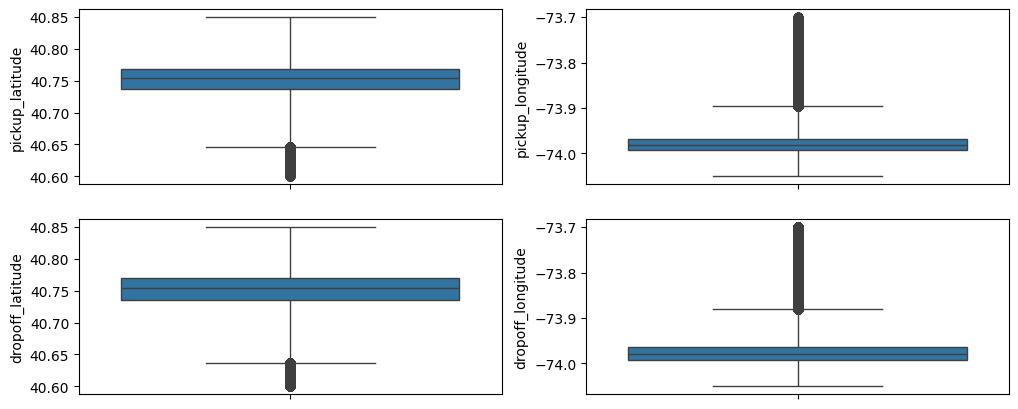

In [22]:
# boxplots for location based columns

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=2, figsize=(12,5))
for i in range(4):
    if i <= 1:
        # plot the boxplot
        sns.boxplot(y=location_subset.iloc[:,i].compute(),ax=ax1[i],whis=3)
    else:
        # plot the boxplot
        sns.boxplot(y=location_subset.iloc[:,i].compute(),ax=ax2[i - 2],whis=3)

<Axes: ylabel='trip_distance'>

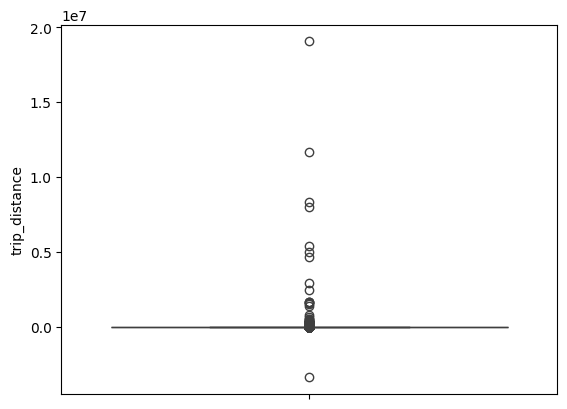

In [23]:
# boxplot for the trip distance

sns.boxplot(df_final.loc[:,"trip_distance"].compute(), whis=3)

<Axes: ylabel='fare_amount'>

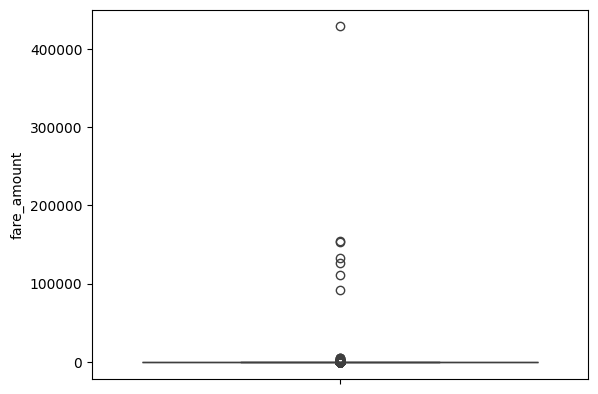

In [24]:
# boxplot for the fare amount

sns.boxplot(df_final.loc[:,"fare_amount"].compute(), whis=3)

<Axes: ylabel='trip_duration_min'>

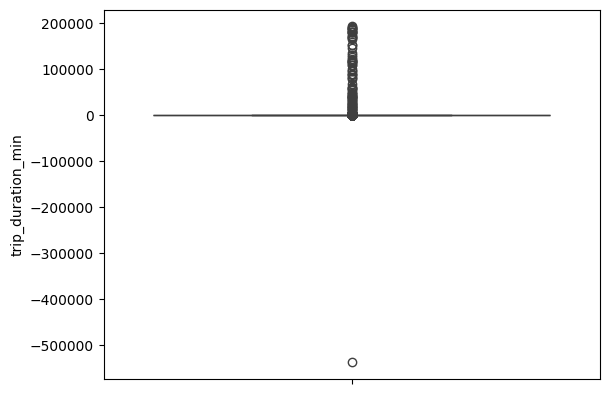

In [25]:
sns.boxplot(df_final.loc[:,"trip_duration_min"].compute(), whis=3)